In [11]:
import kaggle
import matplotlib.pyplot as plt
import numpy as np
import torch as py
import torchmetrics
import torchvision.models as models
import torch.nn.functional as F #sets up the cross entropy loss
from torch import nn
from torch.nn import CrossEntropyLoss
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from PIL import ImageFile
import os
from torch.utils.data import DataLoader, Subset #utilized to test outputs
from torchvision.transforms import ToTensor #creates the necessary vectors corresponding to pixel values
kaggle.api.authenticate()
kaggle.api.dataset_download_files("muhammadrehan00/chest-xray-dataset", path="/kaggle/working",unzip=True) #setting up the dataset utilizing API method (need to select input on right)
!unzip -o -q /kaggle/working/chest-xray-dataset.zip -d /kaggle/working/ #had to be introduced dataset is too large for standard kaggle API command
#confirmation that the dataset is loading in

Dataset URL: https://www.kaggle.com/datasets/muhammadrehan00/chest-xray-dataset
unzip:  cannot find or open /kaggle/working/chest-xray-dataset.zip, /kaggle/working/chest-xray-dataset.zip.zip or /kaggle/working/chest-xray-dataset.zip.ZIP.


In [12]:
def find_dataset_folders(root_dir):
    print(f"--- Scanning: {root_dir} ---")
    if not os.path.exists(root_dir):
        print("Path does not exist!")
        return
        
    for root, dirs, files in os.walk(root_dir):
        # We look for folders that contain our target words
        valid_dirs = [d for d in dirs if 'normal' in d.lower() or 'pneumonia' in d.lower() or 'tuberculosis' in d.lower()]
        if valid_dirs:
            print(f"FOUND CLASS FOLDERS AT: {root}")
            print(f"Subfolders inside it: {dirs}\n")

find_dataset_folders("/kaggle/working")
#this may seem odd, but due to the large amount of data contained within the dataset we need to confirm all folders are there (I ran into an issue where the training set only had "normal" photos!).

--- Scanning: /kaggle/working ---
FOUND CLASS FOLDERS AT: /kaggle/working/test
Subfolders inside it: ['pneumonia', 'tuberculosis', 'normal']

FOUND CLASS FOLDERS AT: /kaggle/working/val
Subfolders inside it: ['pneumonia', 'tuberculosis', 'normal']

FOUND CLASS FOLDERS AT: /kaggle/working/train
Subfolders inside it: ['pneumonia', 'tuberculosis', 'normal']



In [13]:
GPU = py.device("cuda" if py.cuda.is_available() else "cpu")
print(f"Using device: {GPU}")
#preparing to utilize the GPU as opposed to CPU

Using device: cuda


In [14]:
image_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomRotation(degrees=15), #adds random rotation to images to help the program learn actual characteristics of the data as opposed to standard coordinates
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #normalizes the data to assist with learning rates
]) 
#This creates all the images to same size, higher resolution means more accurate image but more GPU usage. Typically stick to multiples of 32.

train_dataset = ImageFolder(
    root="/kaggle/working/train",
    transform=image_resize
)
#loading the data into training set.

test_dataset = ImageFolder(
    root="/kaggle/working/test",
    transform=image_resize
)
#Another portion of the data goes into a testing set.

train_size = 1250
random_train_index = np.random.choice(len(train_dataset), size=train_size, replace=False)
train_subset = Subset(train_dataset, random_train_index)
#This is creating smaller testing subset to help speed up testing of the model.

test_size = 500
random_test_index = np.random.choice(len(test_dataset), size=test_size, replace=False)
test_subset = Subset(test_dataset, random_test_index)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9607843].


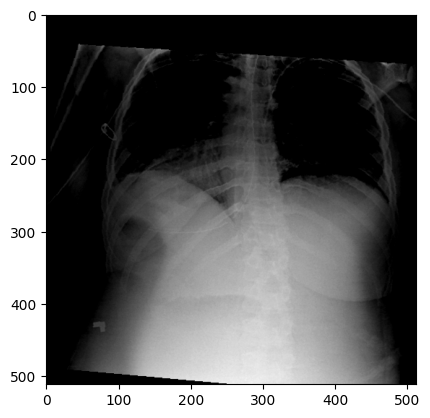

In [15]:
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4) #can swap "train_subset" and "train_dataset" for model testing.
data_iter = iter(train_loader)
images, labels = next(data_iter)
img= images[0] #checks the training dataset with a random sample of 32 and returns 1 random image.
img_numpy = img.permute(1, 2, 0).numpy() #numpy and matplotlib store values differently, must be permutated to match specifications.
plt.imshow(img_numpy) #ensuring images are loading correctly.

test_loader = DataLoader(
    test_subset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=4
)

In [16]:
num_classes = 3 #number of classes
task_type = "multiclass"
precision = torchmetrics.Precision(task="multiclass", num_classes=3, average="macro")
confusion_matrix_metrics = torchmetrics.classification.MulticlassConfusionMatrix(num_classes=3, normalize=None).to(GPU)

In [17]:
model = models.resnet18(weights=None) #the model choice is somewhat arbirtary but resnet18 is generally agreed to be a good choice for small datasets 
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)
model= model.to(GPU)

criterion = nn.CrossEntropyLoss() #notably it applies a softmax as well
optimizer = py.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [18]:
number_epochs = 5 #number of times to train the data
model.train()  # Tell the model it is time to learn
for epoch in range(number_epochs): #refines the data and compares to loss function
    running_loss = 0.0
    for images, dummy_targets in train_loader:
        images = images.to(GPU)
        dummy_targets = dummy_targets.to(GPU) # moves the dataset to be processed on the GPU as opposed to CPU 
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, dummy_targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss/len(train_loader)
    print(f"Epoch {epoch+1}/{number_epochs} | Average loss: {epoch_loss:.4f}")

print("Train complete")

Epoch 1/5 | Average loss: 1.0283
Epoch 2/5 | Average loss: 0.9212
Epoch 3/5 | Average loss: 0.8555
Epoch 4/5 | Average loss: 0.7816
Epoch 5/5 | Average loss: 0.7266
Train complete


Final 3x3 Confusion Matrix:
 tensor([[141,  55,   3],
        [ 10, 104,   1],
        [ 96,  40,  50]], device='cuda:0')


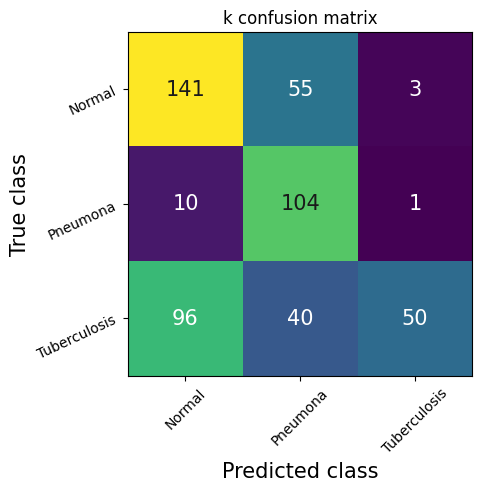

In [19]:
f1_metric = torchmetrics.classification.MulticlassF1Score( num_classes=3, average="macro").to(GPU)
accuracy_metric = torchmetrics.classification.MulticlassAccuracy(num_classes=3, average="micro").to(GPU)
model.eval() 
with py.no_grad():
    for images, targets in test_loader:
        images = images.to(GPU)
        targets = targets.to(GPU)
        outputs = model(images)
        predictions = py.argmax(outputs, dim=1)
        confusion_matrix_metrics.update(predictions, targets)
        f1_metric.update(predictions, targets)
        accuracy_metric.update(predictions, targets)

final_confusion_matrix = confusion_matrix_metrics.compute()
print("Final 3x3 Confusion Matrix:\n", final_confusion_matrix)

fig, ax = confusion_matrix_metrics.plot(labels=["Normal", "Pneumona", "Tuberculosis"])
plt.title("k confusion matrix")
plt.show()

In [20]:
f1_score = f1_metric.compute()
accuracy = accuracy_metric.compute()
print(f"F-1 score is: {f1_score.item():.4f}")
print(f"Accuracy is: {accuracy.item():.4f}")


F-1 score is: 0.5705
Accuracy is: 0.5900


In [21]:
confusion_matrix_metrics.reset()